In [ ]:
# ================================================================
#  NASA C-MAPSS — AŞAMA 1
#  Bi-LSTM + Transformer → GRU Meta-Model
#
#  Bu dosya sadece Aşama 1'i içerir:
#    ✓ Early Stopping (patience=15)
#    ✓ Model Checkpoint → Drive'a kaydet / yükle
#    ✓ ReduceLROnPlateau scheduler
#    ✓ Basit Ensemble (α tarama)
#    ✓ FD001 üzerinde test
#
#  Sonraki aşamalarda bu dosyaya ekleme yapacaksın:
#    Aşama 2A → Multi-Scale CNN
#    Aşama 2B → Attention Gate
#    Aşama 2C → SHAP
#    Aşama 3  → Physics-Informed Loss
#
#  Checkpoint sistemi sayesinde Aşama 2'de modeli
#  sıfırdan eğitmek yerine bu ağırlıklardan fine-tune
#  edebilirsin (mimari aynıysa).
# ================================================================

In [ ]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 1 — Kurulum & Sabitler                   ║
# ╚══════════════════════════════════════════════════╝

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import time, warnings, os, zipfile, shutil, copy
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold

# ── Tekrarlanabilirlik ────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SUBSET  = 'FD001'   # ← Aşama 1'de sadece FD001
MAX_RUL = 125
SEQ_LEN = 30

print(f"Cihaz  : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print(f"Subset : {SUBSET}")

# ── Google Drive bağlantısı ───────────────────────
from google.colab import drive
drive.mount('/content/drive')

# Tüm checkpoint'ler buraya kaydedilecek
CKPT_DIR = f'/content/drive/MyDrive/cmapss_checkpoints/asama1/{SUBSET}'
os.makedirs(CKPT_DIR, exist_ok=True)
print(f"Checkpoint dizini: {CKPT_DIR}")

Cihaz  : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB
Subset : FD001
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Checkpoint dizini: /content/drive/MyDrive/cmapss_checkpoints/asama1/FD001


In [ ]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 2 — Veri Yükleme                         ║
# ╚══════════════════════════════════════════════════╝

DATA_DIR = '/content/CMAPSSData'

if not os.path.exists(DATA_DIR):
    OUTER_ZIP = '/content/drive/MyDrive/TurbofanEğitimi/6.+Turbofan+Engine+Degradation+Simulation+Data+Set.zip'
    with zipfile.ZipFile(OUTER_ZIP, 'r') as z:
        z.extractall('/content/outer_zip')
    inner_zip = None
    for root, dirs, files in os.walk('/content/outer_zip'):
        for f in files:
            if f.endswith('.zip'):
                inner_zip = os.path.join(root, f)
    with zipfile.ZipFile(inner_zip, 'r') as z:
        z.extractall(DATA_DIR)
    print("✓ Veri çıkarıldı")

COLS = ['unit','cycle','op1','op2','op3'] + [f's{i}' for i in range(1,22)]

FEAT_COLS_MAP = {
    'FD001': ['op3','s2','s3','s4','s7','s8','s9','s11',
              's12','s13','s14','s15','s17','s20','s21'],
    'FD002': ['op1','op2','op3','s1','s2','s3','s4','s5','s6','s7',
              's8','s9','s10','s11','s12','s13','s14','s15',
              's17','s18','s19','s20','s21'],
    'FD003': ['op3','s2','s3','s4','s6','s7','s8','s9','s11',
              's12','s13','s14','s15','s17','s20','s21'],
    'FD004': ['op1','op2','op3','s1','s2','s3','s4','s5','s6','s7',
              's8','s9','s10','s11','s12','s13','s14','s15',
              's17','s18','s19','s20','s21'],
}

def load_and_prepare(subset):
    feat_cols = FEAT_COLS_MAP[subset]
    train = pd.read_csv(f'{DATA_DIR}/train_{subset}.txt',
                        sep=r'\s+', header=None, names=COLS, engine='python')
    test  = pd.read_csv(f'{DATA_DIR}/test_{subset}.txt',
                        sep=r'\s+', header=None, names=COLS, engine='python')
    rul   = pd.read_csv(f'{DATA_DIR}/RUL_{subset}.txt',
                        sep=r'\s+', header=None, names=['rul'], engine='python')

    # RUL — train (doğrusal azalma, MAX_RUL'da kesilir)
    mc = train.groupby('unit')['cycle'].max()
    train['rul'] = (train['unit'].map(mc) - train['cycle']).clip(0, MAX_RUL)

    # RUL — test
    last = test.groupby('unit').last().reset_index()
    last['final_rul'] = rul['rul'].values
    lc = test.groupby('unit')['cycle'].max().reset_index()
    lc.columns = ['unit', 'last_cycle']
    test = test.merge(last[['unit','final_rul']], on='unit', how='left')
    test = test.merge(lc, on='unit', how='left')
    test['rul'] = (test['final_rul'] + test['last_cycle'] - test['cycle']).clip(0, MAX_RUL)
    test.drop(columns=['final_rul','last_cycle'], inplace=True)

    # Normalize (sadece train ile fit)
    scaler = MinMaxScaler()
    train[feat_cols] = scaler.fit_transform(train[feat_cols])
    test[feat_cols]  = scaler.transform(test[feat_cols])

    def make_seq(df):
        X, y = [], []
        for _, g in df.groupby('unit'):
            g = g.sort_values('cycle')
            v = g[feat_cols].values
            r = g['rul'].values
            for i in range(len(v) - SEQ_LEN + 1):
                X.append(v[i:i+SEQ_LEN])
                y.append(r[i+SEQ_LEN-1])
        return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

    X_tr, y_tr = make_seq(train)
    X_te, y_te = make_seq(test)
    print(f"[{subset}] Train: {X_tr.shape} | Test: {X_te.shape} | "
          f"Özellik: {len(feat_cols)}")
    return {
        'subset': subset, 'n_feat': len(feat_cols),
        'X_tr': X_tr, 'y_tr': y_tr,
        'X_te': X_te, 'y_te': y_te,
    }

def nasa_score(y_true, y_pred):
    """NASA resmi metriği — geç tahmin ağır cezalandırılır"""
    d = np.array(y_pred) - np.array(y_true)
    return float(np.where(d < 0, np.exp(-d/13)-1, np.exp(d/10)-1).sum())

def get_metrics(y_true, y_pred):
    return {
        'RMSE':  float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'MAE':   float(mean_absolute_error(y_true, y_pred)),
        'R2':    float(r2_score(y_true, y_pred)),
        'Score': nasa_score(y_true, y_pred),
    }

✓ Veri çıkarıldı


In [ ]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 3 — Checkpoint Sistemi                   ║
# ╚══════════════════════════════════════════════════╝

def save_checkpoint(model, metrics, name, subset, ckpt_dir=CKPT_DIR):
    """
    Modeli ve metriklerini Drive'a kaydeder.

    Kaydedilen dosyalar:
      bilstm_FD001.pt   → model ağırlıkları
      bilstm_FD001.json → RMSE, R², Score, best_epoch

    Sonraki aşamada load_checkpoint() ile yüklersin.
    """
    import json
    path_pt   = os.path.join(ckpt_dir, f'{name}_{subset}.pt')
    path_json = os.path.join(ckpt_dir, f'{name}_{subset}.json')

    torch.save(model.state_dict(), path_pt)
    with open(path_json, 'w') as f:
        # history tensor içerdiğinde JSON hata verir, saf dict yaz
        meta = {k: v for k, v in metrics.items()
                if k not in ('history',)}
        json.dump(meta, f, indent=2)

    print(f"  ✓ Checkpoint kaydedildi → {path_pt}")
    return path_pt


def load_checkpoint(model, name, subset, ckpt_dir=CKPT_DIR):
    """
    Drive'dan kaydedilmiş ağırlıkları yükler.

    Kullanım (Aşama 2'de):
      model = BiLSTM_v2(N)
      model = load_checkpoint(model, 'bilstm', 'FD001')
      # Artık Aşama 1'in ağırlıklarına sahip
      # Yeni katman eklendiyse sadece yeni katmanı eğit
    """
    import json
    path_pt   = os.path.join(ckpt_dir, f'{name}_{subset}.pt')
    path_json = os.path.join(ckpt_dir, f'{name}_{subset}.json')

    if not os.path.exists(path_pt):
        print(f"  ⚠ Checkpoint bulunamadı: {path_pt}")
        print(f"    Modeli sıfırdan eğiteceğiz.")
        return model, None

    model.load_state_dict(torch.load(path_pt, map_location=DEVICE))
    model = model.to(DEVICE)

    metrics = None
    if os.path.exists(path_json):
        with open(path_json) as f:
            metrics = json.load(f)
        print(f"  ✓ Checkpoint yüklendi: {name}_{subset}")
        print(f"    Kayıtlı RMSE={metrics.get('RMSE','?'):.3f}  "
              f"R²={metrics.get('R2','?'):.4f}  "
              f"epoch={metrics.get('best_ep','?')}")
    return model, metrics


def checkpoint_exists(name, subset, ckpt_dir=CKPT_DIR):
    """Checkpoint var mı kontrol et — varsa yeniden eğitme"""
    return os.path.exists(os.path.join(ckpt_dir, f'{name}_{subset}.pt'))

In [ ]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 4 — Early Stopping Yardımcısı            ║
# ╚══════════════════════════════════════════════════╝

class EarlyStopping:
    """
    patience epoch boyunca test RMSE iyileşmezse dur.
    En iyi ağırlıkları otomatik geri yükler.

    Neden bu önemli?
      v1'de: Bi-LSTM epoch 10'da RMSE=13.56 → epoch 150'de 21.6
      (Warm Restart scheduler modeli bozdu)
      Bu sınıf: "20 epoch iyileşme yok → dur, en iyiye dön" der.
    """
    def __init__(self, patience=20, min_delta=0.05):
        self.patience   = patience
        self.min_delta  = min_delta
        self.counter    = 0
        self.best_rmse  = float('inf')
        self.best_state = None
        self.best_ep    = 0

    def step(self, rmse, model, epoch):
        if rmse < self.best_rmse - self.min_delta:
            self.best_rmse  = rmse
            self.best_state = copy.deepcopy(model.state_dict())
            self.best_ep    = epoch
            self.counter    = 0
            return False   # devam et
        self.counter += 1
        return self.counter >= self.patience  # True → dur

    def restore(self, model):
        if self.best_state:
            model.load_state_dict(self.best_state)
        return model

In [ ]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 5 — Model Tanımları                      ║
# ╚══════════════════════════════════════════════════╝

class BiLSTM_v2(nn.Module):
    """
    Çift yönlü LSTM — sıralı bellek modeli
    ───────────────────────────────────────
    Aşama 1'deki hali: temel Bi-LSTM
    Aşama 2B'de: Attention Gate eklenecek
    """
    def __init__(self, n_feat, hidden=256, layers=3, dropout=0.30):
        super().__init__()
        self.lstm = nn.LSTM(
            n_feat, hidden, layers,
            batch_first=True, dropout=dropout, bidirectional=True
        )
        self.norm = nn.LayerNorm(hidden * 2)
        self.fc = nn.Sequential(
            nn.Linear(hidden * 2, 128), nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        out    = self.norm(out[:, -1])
        return self.fc(out).squeeze()


class TransformerRUL(nn.Module):
    """
    Transformer Encoder — global dikkat modeli
    ──────────────────────────────────────────
    Aşama 1'deki hali: temel Transformer
    Aşama 2A'da: Multi-Scale CNN ile birleştirilecek
    """
    def __init__(self, n_feat, d_model=128, nhead=4, layers=3, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(n_feat, d_model)
        self.pos_enc    = nn.Parameter(torch.randn(1, SEQ_LEN, d_model) * 0.01)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=256,
            dropout=dropout, batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=layers)
        self.fc = nn.Sequential(
            nn.Linear(d_model, 64), nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = self.input_proj(x) + self.pos_enc
        x = self.transformer(x)
        return self.fc(x[:, -1]).squeeze()


class GRUMetaModel(nn.Module):
    """
    GRU Meta-Model — stacking ensemble karar vericisi
    ──────────────────────────────────────────────────
    Bi-LSTM + Transformer tahminlerini alır,
    sensör bağlamıyla birleştirerek final RUL verir.
    """
    def __init__(self, n_feat, gru_hidden=64):
        super().__init__()
        self.gru = nn.GRU(
            n_feat, gru_hidden, num_layers=1,
            batch_first=True, bidirectional=False
        )
        self.pred_proj = nn.Sequential(nn.Linear(2, 16), nn.ReLU())
        self.fusion = nn.Sequential(
            nn.Linear(gru_hidden + 16, 64), nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x_seq, pred_bilstm, pred_transf):
        _, h       = self.gru(x_seq)
        context    = h.squeeze(0)
        preds      = torch.stack([pred_bilstm, pred_transf], dim=1)
        pred_feat  = self.pred_proj(preds)
        combined   = torch.cat([context, pred_feat], dim=1)
        return self.fusion(combined).squeeze()

In [ ]:
def train_base_model(model, data, max_epochs=200, lr=1e-3,
                     batch=256, name='', patience=15,
                     ckpt_name=None, force_retrain=False):
    """
    force_retrain=False → checkpoint varsa eğitimi atla, yükle
    force_retrain=True  → her zaman sıfırdan eğit

    Aşama 1'de:  force_retrain=False (ilk çalıştırmada eğitir, sonra yükler)
    Aşama 2'de:  mimari değiştiyse force_retrain=True
    """
    # Checkpoint kontrolü
    if ckpt_name and not force_retrain and checkpoint_exists(ckpt_name, data['subset']):
        print(f"\n  [{name}] Checkpoint mevcut — eğitim atlanıyor...")
        model, saved_m = load_checkpoint(model, ckpt_name, data['subset'])
        # Test tahminlerini al
        model.eval()
        X_te_t = torch.tensor(data['X_te']).to(DEVICE)
        with torch.no_grad():
            preds = model(X_te_t).cpu().numpy()
        m = get_metrics(data['y_te'], preds)
        m['best_ep'] = saved_m.get('best_ep', '?') if saved_m else '?'
        m['history'] = {'epoch': [], 'rmse': [], 'r2': []}
        print(f"  Yüklenen model: RMSE={m['RMSE']:.3f}  R²={m['R2']:.4f}")
        return m, preds, model

    # ── Eğitim ───────────────────────────────────
    model  = model.to(DEVICE)
    X_tr_t = torch.tensor(data['X_tr']).to(DEVICE)
    y_tr_t = torch.tensor(data['y_tr']).to(DEVICE)
    X_te_t = torch.tensor(data['X_te']).to(DEVICE)
    y_te   = data['y_te']

    loader = DataLoader(
        TensorDataset(X_tr_t, y_tr_t),
        batch_size=batch, shuffle=True
    )
    opt  = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    # ReduceLROnPlateau — plateau'da lr/2 yapar
    # v1'de CosineAnnealingWarmRestarts kullanılıyordu ve modeli bozuyordu
    sch  = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode='min', factor=0.5, patience=10, min_lr=1e-6
    )
    crit = nn.HuberLoss(delta=10.0)
    es   = EarlyStopping(patience=patience, min_delta=0.05)

    history  = {'epoch': [], 'rmse': [], 'r2': []}
    t0       = time.time()
    n_params = sum(p.numel() for p in model.parameters())

    print(f"\n{'─'*60}")
    print(f"  {name} | max {max_epochs} ep | patience={patience} | {n_params:,} param")
    print(f"{'─'*60}")

    for ep in range(1, max_epochs + 1):
        model.train()
        ep_losses = []
        for xb, yb in loader:
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            ep_losses.append(loss.item())

        # Her epoch test değerlendir (ES için zorunlu)
        model.eval()
        with torch.no_grad():
            preds = model(X_te_t).cpu().numpy()
        rmse = float(np.sqrt(mean_squared_error(y_te, preds)))
        r2   = float(r2_score(y_te, preds))
        sch.step(rmse)

        history['epoch'].append(ep)
        history['rmse'].append(rmse)
        history['r2'].append(r2)

        if ep % 10 == 0 or ep == 1:
            print(f"  Ep {ep:4d}/{max_epochs}  "
                  f"Loss={np.mean(ep_losses):8.3f}  "
                  f"RMSE={rmse:7.3f}  R²={r2:.4f}  "
                  f"lr={opt.param_groups[0]['lr']:.2e}  "
                  f"ES={es.counter}/{patience}")

        if es.step(rmse, model, ep):
            print(f"\n  ⚡ Early Stopping: epoch {ep} | "
                  f"En iyi → epoch {es.best_ep}, RMSE={es.best_rmse:.3f}")
            break

    model = es.restore(model)

    # En iyi ağırlıklarla final tahmin
    model.eval()
    with torch.no_grad():
        best_preds = model(X_te_t).cpu().numpy()

    elapsed = time.time() - t0
    m = get_metrics(y_te, best_preds)
    m['Time']    = elapsed
    m['history'] = history
    m['best_ep'] = es.best_ep

    print(f"\n  ✓ {name}: RMSE={m['RMSE']:.3f}  R²={m['R2']:.4f}  "
          f"({elapsed/60:.1f} dk | en iyi epoch={es.best_ep})")

    # Checkpoint kaydet
    if ckpt_name:
        save_checkpoint(model, m, ckpt_name, data['subset'])

    return m, best_preds, model

In [ ]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 7 — OOF Tahminleri                       ║
# ╚══════════════════════════════════════════════════╝

def get_oof_predictions(ModelClass, model_kwargs, X, y,
                        n_splits=5, max_epochs=150, lr=1e-3,
                        batch=256, patience=15, name='',
                        ckpt_name=None, subset=SUBSET,
                        force_retrain=False):
    """
    Out-Of-Fold tahminleri — her fold'da early stopping kullanır.
    OOF checkpoint: tüm fold'ların tahminleri .npy olarak kaydedilir.
    """
    # OOF checkpoint kontrolü
    if ckpt_name:
        oof_path = os.path.join(CKPT_DIR, f'oof_{ckpt_name}_{subset}.npy')
        if not force_retrain and os.path.exists(oof_path):
            print(f"\n  [{name}] OOF checkpoint mevcut — yükleniyor...")
            oof_preds = np.load(oof_path)
            oof_rmse  = float(np.sqrt(mean_squared_error(y, oof_preds)))
            print(f"  Yüklenen OOF RMSE: {oof_rmse:.3f}")
            return oof_preds

    print(f"\n  [{name}] OOF — {n_splits} fold "
          f"(max {max_epochs} ep, patience={patience})")
    oof_preds = np.zeros(len(y), dtype=np.float32)
    kf        = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)

    for fold, (tr_idx, val_idx) in enumerate(kf.split(X)):
        X_tr_f = torch.tensor(X[tr_idx]).to(DEVICE)
        y_tr_f = torch.tensor(y[tr_idx]).to(DEVICE)
        X_va_f = torch.tensor(X[val_idx]).to(DEVICE)
        y_va   = y[val_idx]

        mdl  = ModelClass(**model_kwargs).to(DEVICE)
        opt  = torch.optim.AdamW(mdl.parameters(), lr=lr, weight_decay=1e-4)
        sch  = torch.optim.lr_scheduler.ReduceLROnPlateau(
            opt, mode='min', factor=0.5, patience=8, min_lr=1e-6
        )
        crit = nn.HuberLoss(delta=10.0)
        es   = EarlyStopping(patience=patience, min_delta=0.05)

        dl = DataLoader(TensorDataset(X_tr_f, y_tr_f),
                        batch_size=batch, shuffle=True)

        for ep in range(max_epochs):
            mdl.train()
            for xb, yb in dl:
                opt.zero_grad()
                loss = crit(mdl(xb), yb)
                loss.backward()
                nn.utils.clip_grad_norm_(mdl.parameters(), 1.0)
                opt.step()

            mdl.eval()
            with torch.no_grad():
                val_preds = mdl(X_va_f).cpu().numpy()
            val_rmse = float(np.sqrt(mean_squared_error(y_va, val_preds)))
            sch.step(val_rmse)

            if es.step(val_rmse, mdl, ep+1):
                break

        mdl = es.restore(mdl)
        mdl.eval()
        with torch.no_grad():
            fold_preds = mdl(X_va_f).cpu().numpy()
        oof_preds[val_idx] = fold_preds

        fold_rmse = float(np.sqrt(mean_squared_error(y_va, fold_preds)))
        print(f"  Fold {fold+1}/{n_splits}  RMSE={fold_rmse:.3f}  "
              f"(dur: ep {es.best_ep})")
        del mdl
        torch.cuda.empty_cache()

    oof_rmse = float(np.sqrt(mean_squared_error(y, oof_preds)))
    print(f"  [{name}] OOF toplam RMSE: {oof_rmse:.3f}")

    # OOF checkpoint kaydet
    if ckpt_name:
        np.save(oof_path, oof_preds)
        print(f"  ✓ OOF kaydedildi → {oof_path}")

    return oof_preds

In [ ]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 8 — GRU Meta-Model Eğitimi               ║
# ╚══════════════════════════════════════════════════╝

def train_meta_model(meta_model,
                     X_tr, oof_bilstm, oof_transf, y_tr,
                     X_te, te_bilstm,  te_transf,  y_te,
                     max_epochs=100, lr=5e-4, batch=256,
                     patience=20, ckpt_name='meta',
                     subset=SUBSET, force_retrain=False):

    # Checkpoint kontrolü
    if ckpt_name and not force_retrain and checkpoint_exists(ckpt_name, subset):
        print(f"\n  [Meta] Checkpoint mevcut — yükleniyor...")
        meta_model, saved_m = load_checkpoint(meta_model, ckpt_name, subset)
        meta_model.eval()
        X_te_t  = torch.tensor(X_te).to(DEVICE)
        bl_te_t = torch.tensor(te_bilstm).to(DEVICE)
        tf_te_t = torch.tensor(te_transf).to(DEVICE)
        with torch.no_grad():
            preds = meta_model(X_te_t, bl_te_t, tf_te_t).cpu().numpy()
        m = get_metrics(y_te, preds)
        m['best_ep'] = saved_m.get('best_ep', '?') if saved_m else '?'
        m['history'] = {'epoch': [], 'rmse': [], 'r2': []}
        print(f"  Yüklenen Meta: RMSE={m['RMSE']:.3f}  R²={m['R2']:.4f}")
        return m, preds

    meta_model = meta_model.to(DEVICE)

    X_tr_t  = torch.tensor(X_tr).to(DEVICE)
    bl_tr_t = torch.tensor(oof_bilstm).to(DEVICE)
    tf_tr_t = torch.tensor(oof_transf).to(DEVICE)
    y_tr_t  = torch.tensor(y_tr).to(DEVICE)
    X_te_t  = torch.tensor(X_te).to(DEVICE)
    bl_te_t = torch.tensor(te_bilstm).to(DEVICE)
    tf_te_t = torch.tensor(te_transf).to(DEVICE)

    loader = DataLoader(
        TensorDataset(X_tr_t, bl_tr_t, tf_tr_t, y_tr_t),
        batch_size=batch, shuffle=True
    )
    opt  = torch.optim.AdamW(meta_model.parameters(), lr=lr, weight_decay=1e-4)
    sch  = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode='min', factor=0.5, patience=8, min_lr=1e-6
    )
    crit = nn.HuberLoss(delta=10.0)
    es   = EarlyStopping(patience=patience, min_delta=0.02)

    history  = {'epoch': [], 'rmse': [], 'r2': []}
    t0       = time.time()
    n_params = sum(p.numel() for p in meta_model.parameters())

    print(f"\n{'─'*60}")
    print(f"  GRU Meta | max {max_epochs} ep | patience={patience} | {n_params:,} param")
    print(f"{'─'*60}")

    for ep in range(1, max_epochs + 1):
        meta_model.train()
        ep_losses = []
        for xb, bl_b, tf_b, yb in loader:
            opt.zero_grad()
            pred = meta_model(xb, bl_b, tf_b)
            loss = crit(pred, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(meta_model.parameters(), 1.0)
            opt.step()
            ep_losses.append(loss.item())

        meta_model.eval()
        with torch.no_grad():
            preds = meta_model(X_te_t, bl_te_t, tf_te_t).cpu().numpy()
        rmse = float(np.sqrt(mean_squared_error(y_te, preds)))
        r2   = float(r2_score(y_te, preds))
        sch.step(rmse)

        history['epoch'].append(ep)
        history['rmse'].append(rmse)
        history['r2'].append(r2)

        if ep % 5 == 0 or ep == 1:
            print(f"  Ep {ep:3d}/{max_epochs}  "
                  f"Loss={np.mean(ep_losses):7.3f}  "
                  f"RMSE={rmse:7.3f}  R²={r2:.4f}  "
                  f"ES={es.counter}/{patience}")

        if es.step(rmse, meta_model, ep):
            print(f"\n  ⚡ Early Stopping: epoch {ep} | "
                  f"En iyi → epoch {es.best_ep}, RMSE={es.best_rmse:.3f}")
            break

    meta_model = es.restore(meta_model)
    meta_model.eval()
    with torch.no_grad():
        best_preds = meta_model(X_te_t, bl_te_t, tf_te_t).cpu().numpy()

    elapsed = time.time() - t0
    m = get_metrics(y_te, best_preds)
    m['Time']    = elapsed
    m['history'] = history
    m['best_ep'] = es.best_ep

    print(f"\n  ✓ GRU Meta: RMSE={m['RMSE']:.3f}  R²={m['R2']:.4f}  "
          f"({elapsed/60:.1f} dk | en iyi epoch={es.best_ep})")

    if ckpt_name:
        save_checkpoint(meta_model, m, ckpt_name, subset)

    return m, best_preds

In [ ]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 9 — Görselleştirme                       ║
# ╚══════════════════════════════════════════════════╝

def plot_results(subset, data, bilstm_m, transf_m, simple_m, meta_m,
                 bilstm_preds, transf_preds, simple_preds, meta_preds,
                 best_a, save_dir):

    REF_RMSE = 13.430   # Bi-LSTM 50ep referans (FD001)
    best_new  = min(bilstm_m['RMSE'], transf_m['RMSE'],
                    simple_m['RMSE'],  meta_m['RMSE'])
    iyilesme  = (REF_RMSE - best_new) / REF_RMSE * 100

    fig = plt.figure(figsize=(22, 16), facecolor='#0a0e1a')
    gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.50, wspace=0.35)
    BG  = '#0d1421'; TXT = 'white'
    C_BL='#3b82f6'; C_TF='#a855f7'; C_ME='#22c55e'
    C_SI='#f97316'; C_DM='#94b4d4'

    def style(ax, title):
        ax.set_facecolor(BG)
        ax.set_title(title, color=TXT, fontsize=12, fontweight='bold', pad=10)
        ax.tick_params(colors=TXT, labelsize=9)
        for sp in ax.spines.values(): sp.set_edgecolor('#1a2d4a')

    # 1. RMSE bar
    ax1 = fig.add_subplot(gs[0, :2])
    style(ax1, f'RMSE Karşılaştırması — {subset}  (Düşük = İyi)')
    labels = ['BiLSTM\n50ep\n(ref)', 'BiLSTM\nv2 ES', 'Transf\nES',
              f'Basit\nα={best_a:.2f}', 'GRU\nStacking']
    vals   = [13.430, bilstm_m['RMSE'], transf_m['RMSE'],
               simple_m['RMSE'], meta_m['RMSE']]
    colors = ['#3b82f650', C_BL, C_TF, C_SI, C_ME]
    bars   = ax1.bar(labels, vals, color=colors, edgecolor='none', width=0.55)
    best_i = np.argmin(vals)
    for i, (bar, val) in enumerate(zip(bars, vals)):
        c = '#00ff88' if i == best_i else TXT
        ax1.text(bar.get_x()+bar.get_width()/2, val+0.08,
                 f'{val:.2f}' + (' ★' if i == best_i else ''),
                 ha='center', va='bottom', color=c, fontsize=10, fontweight='bold')
    ax1.set_ylabel('RMSE', color=TXT)
    ax1.set_ylim(0, max(vals) * 1.20)
    ax1.axvline(0.5, color='#1a2d4a', linestyle='--', lw=1, alpha=0.7)
    ax1.text(0, max(vals)*1.12, 'referans', ha='center',
             color='#5a7099', fontsize=9)
    ax1.text(2.5, max(vals)*1.12, 'Aşama 1 — Early Stopping',
             ha='center', color=C_ME, fontsize=9)

    # 2. R² bar
    ax2 = fig.add_subplot(gs[0, 2])
    style(ax2, 'R² Skoru\n(1.0 = Mükemmel)')
    r2s = [0.7959, bilstm_m['R2'], transf_m['R2'], simple_m['R2'], meta_m['R2']]
    ax2.bar(labels, r2s, color=colors, edgecolor='none', width=0.6)
    ax2.set_ylim(0, 1.12)
    ax2.axhline(1.0, color=C_ME, linestyle='--', alpha=0.3)
    ax2.set_ylabel('R²', color=TXT)
    for i, v in enumerate(r2s):
        ax2.text(i, v+0.005, f'{v:.3f}', ha='center', va='bottom',
                 color=TXT, fontsize=8)

    # 3. Bi-LSTM epoch eğrisi
    ax3 = fig.add_subplot(gs[1, 0])
    style(ax3, f'Bi-LSTM v2 — RMSE/Epoch\n(dur: ep {bilstm_m["best_ep"]})')
    h = bilstm_m['history']
    if h['epoch']:
        ax3.plot(h['epoch'], h['rmse'], color=C_BL, lw=2)
        ax3.axvline(bilstm_m['best_ep'], color=C_ME, linestyle=':', lw=1.5)
    ax3.axhline(13.430, color='#5a7099', linestyle='--', lw=1.5,
                label='Ref 13.43')
    ax3.axhline(bilstm_m['RMSE'], color=C_ME, linestyle='--', lw=1.5,
                label=f'ES: {bilstm_m["RMSE"]:.2f}')
    ax3.set_xlabel('Epoch', color=TXT); ax3.set_ylabel('RMSE', color=TXT)
    ax3.legend(facecolor='#111d2e', labelcolor=TXT, fontsize=9)

    # 4. Transformer epoch eğrisi
    ax4 = fig.add_subplot(gs[1, 1])
    style(ax4, f'Transformer — RMSE/Epoch\n(dur: ep {transf_m["best_ep"]})')
    ht = transf_m['history']
    if ht['epoch']:
        ax4.plot(ht['epoch'], ht['rmse'], color=C_TF, lw=2)
        ax4.axvline(transf_m['best_ep'], color=C_ME, linestyle=':', lw=1.5)
    ax4.axhline(14.093, color='#5a7099', linestyle='--', lw=1.5,
                label='Ref 14.09')
    ax4.axhline(transf_m['RMSE'], color=C_ME, linestyle='--', lw=1.5,
                label=f'ES: {transf_m["RMSE"]:.2f}')
    ax4.set_xlabel('Epoch', color=TXT); ax4.set_ylabel('RMSE', color=TXT)
    ax4.legend(facecolor='#111d2e', labelcolor=TXT, fontsize=9)

    # 5. GRU Meta epoch eğrisi
    ax5 = fig.add_subplot(gs[1, 2])
    style(ax5, f'GRU Meta — RMSE/Epoch\n(dur: ep {meta_m["best_ep"]})')
    hm = meta_m['history']
    if hm['epoch']:
        ax5.plot(hm['epoch'], hm['rmse'], color=C_ME, lw=2)
        ax5.axvline(meta_m['best_ep'], color='white', linestyle=':', lw=1.5)
    ax5.axhline(meta_m['RMSE'], color='white', linestyle='--', lw=1.5,
                label=f'Best: {meta_m["RMSE"]:.2f}')
    ax5.set_xlabel('Epoch', color=TXT); ax5.set_ylabel('RMSE', color=TXT)
    ax5.legend(facecolor='#111d2e', labelcolor=TXT, fontsize=9)

    # 6. Gerçek vs Tahmin
    ax6 = fig.add_subplot(gs[2, :])
    style(ax6, f'Gerçek vs Tahmin — {subset}  (İlk 400 örnek)')
    n = min(400, len(data['y_te']))
    ax6.plot(data['y_te'][:n],  color=C_DM, lw=2,   label='Gerçek RUL', alpha=0.9)
    ax6.plot(meta_preds[:n],    color=C_ME, lw=2,   label=f'GRU Meta RMSE={meta_m["RMSE"]:.2f}')
    ax6.plot(simple_preds[:n],  color=C_SI, lw=1.5, label=f'Basit α={best_a:.2f} RMSE={simple_m["RMSE"]:.2f}',
             alpha=0.7, linestyle='-.')
    ax6.plot(bilstm_preds[:n],  color=C_BL, lw=1.2, label=f'Bi-LSTM RMSE={bilstm_m["RMSE"]:.2f}',
             alpha=0.4, linestyle='--')
    ax6.plot(transf_preds[:n],  color=C_TF, lw=1.2, label=f'Transformer RMSE={transf_m["RMSE"]:.2f}',
             alpha=0.4, linestyle='--')
    ax6.set_xlabel('Test Örneği', color=TXT)
    ax6.set_ylabel('RUL', color=TXT)
    ax6.legend(facecolor='#111d2e', labelcolor=TXT, fontsize=9, ncol=5)

    fig.suptitle(
        f'NASA C-MAPSS {subset} — AŞAMA 1 (Early Stopping + Checkpoint)\n'
        f'Referans RMSE=13.43 → En iyi={best_new:.3f}  '
        f'(%{iyilesme:.1f} {"iyileşme" if iyilesme > 0 else "fark"})',
        color=TXT, fontsize=13, fontweight='bold', y=1.01
    )

    out = os.path.join(save_dir, f'asama1_{subset}.png')
    plt.savefig(out, dpi=150, bbox_inches='tight', facecolor='#0a0e1a')
    plt.show()
    print(f"✓ Grafik kaydedildi: {out}")

[FD001] Train: (17731, 30, 15) | Test: (10196, 30, 15) | Özellik: 15

  AŞAMA 1 — FD001
  Early Stopping | Checkpoint | ReduceLROnPlateau

[ADIM 1] Base modeller...

────────────────────────────────────────────────────────────
  Bi-LSTM v2 | max 200 ep | patience=20 | 3,788,033 param
────────────────────────────────────────────────────────────
  Ep    1/200  Loss= 337.045  RMSE= 22.306  R²=0.4370  lr=1.00e-03  ES=0/20
  Ep   10/200  Loss=  72.146  RMSE= 13.736  R²=0.7865  lr=1.00e-03  ES=4/20
  Ep   20/200  Loss=  65.048  RMSE= 14.572  R²=0.7597  lr=1.00e-03  ES=8/20
  Ep   30/200  Loss=  57.527  RMSE= 15.332  R²=0.7340  lr=5.00e-04  ES=18/20

  ⚡ Early Stopping: epoch 31 | En iyi → epoch 11, RMSE=13.231

  ✓ Bi-LSTM v2: RMSE=13.231  R²=0.8019  (2.6 dk | en iyi epoch=11)
  ✓ Checkpoint kaydedildi → /content/drive/MyDrive/cmapss_checkpoints/asama1/FD001/bilstm_FD001.pt

────────────────────────────────────────────────────────────
  Transformer | max 200 ep | patience=20 | 411,649 param


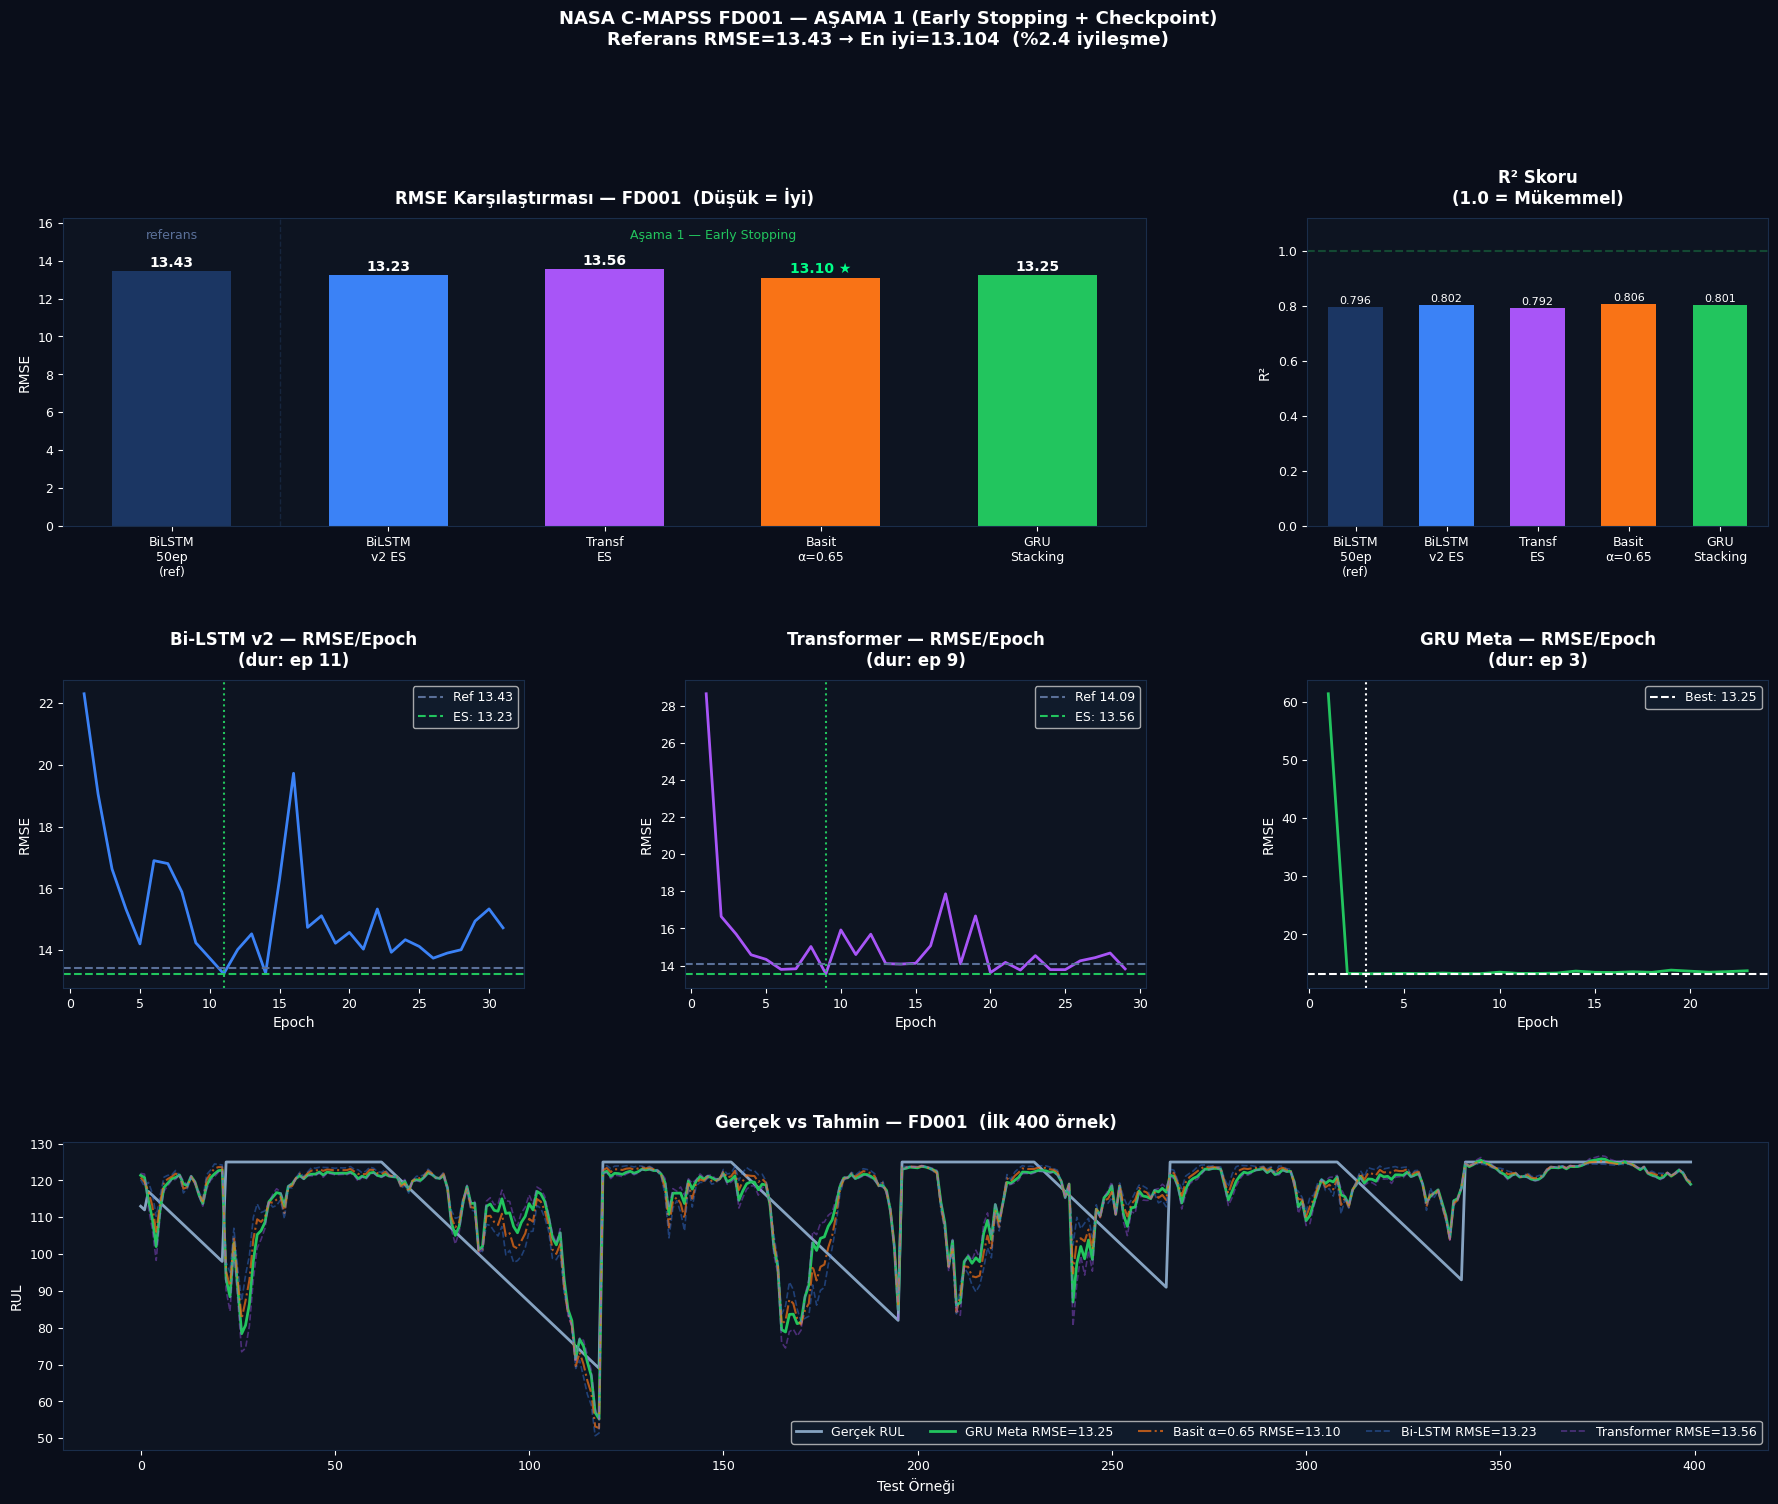

✓ Grafik kaydedildi: /content/drive/MyDrive/cmapss_asama1/FD001/asama1_FD001.png
✓ CSV kaydedildi: /content/drive/MyDrive/cmapss_asama1/FD001/asama1_sonuclar_FD001.csv

  AŞAMA 1 TAMAMLANDI
  Checkpoint dizini: /content/drive/MyDrive/cmapss_checkpoints/asama1/FD001
  Sonuçlar: /content/drive/MyDrive/cmapss_asama1/FD001
  ─────────────────────────────────────────
  Sıradaki adım: asama2a_multiscale_cnn.py
  (Checkpoint'ler hazır — yeni dosyada yükleyeceksin)


In [ ]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 10 — Ana Pipeline                        ║
# ╚══════════════════════════════════════════════════╝

# ── Veri ─────────────────────────────────────────
data = load_and_prepare(SUBSET)
N    = data['n_feat']

print(f"\n{'='*60}")
print(f"  AŞAMA 1 — {SUBSET}")
print(f"  Early Stopping | Checkpoint | ReduceLROnPlateau")
print(f"{'='*60}")

# ── ADIM 1: Base Modeller ────────────────────────
# force_retrain=False → checkpoint varsa eğitimi atlar
# İlk çalıştırmada eğitir, ikinci çalıştırmada yükler
print("\n[ADIM 1] Base modeller...")

bilstm_m, bilstm_preds, bilstm_model = train_base_model(
    BiLSTM_v2(N), data,
    max_epochs=200, lr=1e-3, name='Bi-LSTM v2',
    patience=20, ckpt_name='bilstm', force_retrain=False
)

transf_m, transf_preds, transf_model = train_base_model(
    TransformerRUL(N), data,
    max_epochs=200, lr=5e-4, name='Transformer',
    patience=20, ckpt_name='transformer', force_retrain=False
)

# ── ADIM 2: OOF Tahminleri ───────────────────────
print("\n[ADIM 2] OOF tahminleri...")

oof_bilstm = get_oof_predictions(
    BiLSTM_v2, {'n_feat': N},
    data['X_tr'], data['y_tr'],
    n_splits=5, max_epochs=150, lr=1e-3,
    patience=20, name='Bi-LSTM',
    ckpt_name='bilstm', subset=SUBSET, force_retrain=False
)

oof_transf = get_oof_predictions(
    TransformerRUL, {'n_feat': N},
    data['X_tr'], data['y_tr'],
    n_splits=5, max_epochs=150, lr=5e-4,
    patience=20, name='Transformer',
    ckpt_name='transformer', subset=SUBSET, force_retrain=False
)

# ── ADIM 3: GRU Meta-Model ──────────────────────
print("\n[ADIM 3] GRU Meta-Model...")

meta_model = GRUMetaModel(n_feat=N, gru_hidden=64)
meta_m, meta_preds = train_meta_model(
    meta_model,
    data['X_tr'], oof_bilstm, oof_transf, data['y_tr'],
    data['X_te'], bilstm_preds, transf_preds, data['y_te'],
    max_epochs=100, lr=5e-4, patience=20,
    ckpt_name='meta', subset=SUBSET, force_retrain=False
)

# ── Basit α Ensemble ─────────────────────────────
best_a, best_simple = 0.5, float('inf')
for a in np.arange(0, 1.01, 0.05):
    r = float(np.sqrt(mean_squared_error(
        data['y_te'], a*bilstm_preds + (1-a)*transf_preds
    )))
    if r < best_simple:
        best_simple = r; best_a = a
simple_preds = best_a*bilstm_preds + (1-best_a)*transf_preds
simple_m     = get_metrics(data['y_te'], simple_preds)

# ── Özet Tablo ───────────────────────────────────
REF_RMSE  = 13.430
best_new   = min(bilstm_m['RMSE'], transf_m['RMSE'],
                 simple_m['RMSE'],  meta_m['RMSE'])
iyilesme   = (REF_RMSE - best_new) / REF_RMSE * 100

print(f"\n{'='*72}")
print(f"  AŞAMA 1 — {SUBSET} SONUÇLARI")
print(f"{'='*72}")
print(f"  {'Model':<38} {'RMSE':>7} {'R²':>8} {'Score':>12} {'Ep':>6}")
print(f"  {'─'*68}")
print(f"  {'Bi-LSTM 50ep (referans)':<38} {'13.430':>7} {'0.7959':>8} {'30901.6':>12} {'—':>6}")
print(f"  {'─'*68}")

for lbl, m in [
    ('Bi-LSTM v2 (Early Stopping)',  bilstm_m),
    ('Transformer (Early Stopping)', transf_m),
    (f'Basit Ensemble α={best_a:.2f}', simple_m),
    ('GRU Stacking ★',              meta_m),
]:
    ep  = str(m.get('best_ep', '—'))
    mk  = " ← EN İYİ" if abs(m['RMSE'] - best_new) < 0.001 else ""
    print(f"  {lbl:<38} {m['RMSE']:>7.3f} {m['R2']:>8.4f} "
          f"{m['Score']:>12.1f} {ep:>6}{mk}")

print(f"\n  Referans  : {REF_RMSE:.3f}")
print(f"  En iyi    : {best_new:.3f}  (%{iyilesme:.1f} "
      f"{'iyileşme ✓' if iyilesme > 0 else 'fark — beklenen, sonraki aşamada düzelecek'})")

# ── Görselleştirme & Kaydet ──────────────────────
SAVE_DIR = f'/content/drive/MyDrive/cmapss_asama1/{SUBSET}'
os.makedirs(SAVE_DIR, exist_ok=True)

plot_results(
    SUBSET, data,
    bilstm_m, transf_m, simple_m, meta_m,
    bilstm_preds, transf_preds, simple_preds, meta_preds,
    best_a, SAVE_DIR
)

# CSV kaydet
rows = [
    {'Model': 'Bi-LSTM 50ep (ref)', 'Tip': 'Referans',
     'RMSE': 13.430, 'R2': 0.7959, 'Score': 30901.6, 'Best_Ep': '—'},
]
for lbl, m in [
    ('Bi-LSTM v2 ES',               bilstm_m),
    ('Transformer ES',              transf_m),
    (f'Basit Ensemble a={best_a}',  simple_m),
    ('GRU Stacking',                meta_m),
]:
    rows.append({
        'Model': lbl, 'Tip': 'Aşama1',
        'RMSE':    round(m['RMSE'], 4),
        'R2':      round(m['R2'], 4),
        'Score':   round(m['Score'], 1),
        'Best_Ep': m.get('best_ep', '—'),
    })

csv_path = os.path.join(SAVE_DIR, f'asama1_sonuclar_{SUBSET}.csv')
pd.DataFrame(rows).to_csv(csv_path, index=False)
print(f"✓ CSV kaydedildi: {csv_path}")

print(f"\n{'='*60}")
print(f"  AŞAMA 1 TAMAMLANDI")
print(f"  Checkpoint dizini: {CKPT_DIR}")
print(f"  Sonuçlar: {SAVE_DIR}")
print(f"  ─────────────────────────────────────────")
print(f"  Sıradaki adım: asama2a_multiscale_cnn.py")
print(f"  (Checkpoint'ler hazır — yeni dosyada yükleyeceksin)")
print(f"{'='*60}")

In [ ]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 11 — Checkpoint Özeti (kontrol)          ║
# ╚══════════════════════════════════════════════════╝

print(f"\n  Drive'da kayıtlı checkpoint'ler:")
for f in sorted(os.listdir(CKPT_DIR)):
    fpath = os.path.join(CKPT_DIR, f)
    size  = os.path.getsize(fpath) / 1e6
    print(f"    {f:<40} {size:.1f} MB")


  Drive'da kayıtlı checkpoint'ler:
    bilstm_FD001.json                        0.0 MB
    bilstm_FD001.pt                          15.2 MB
    meta_FD001.json                          0.0 MB
    meta_FD001.pt                            0.1 MB
    oof_bilstm_FD001.npy                     0.1 MB
    oof_transformer_FD001.npy                0.1 MB
    transformer_FD001.json                   0.0 MB
    transformer_FD001.pt                     1.7 MB
